# Segmentación COVID

## 1. Importación
Primero se importan las librerías que vamos a estar utilizando en el proyecto. Y al final imprimimos que estaríamos usando para entrenar al modelo si cpu o gpu.

In [35]:
import torch
import scipy
import cv2
import os
import time
import albumentations
import numpy                        as np # linear algebra
import pandas                       as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot            as plt
import segmentation_models_pytorch  as smp
import torch.nn.functional          as F
import torch.nn                     as nn
# Barra de progreso compatible con Jupyter aunque ipywidgets/IProgress no esté instalado
from tqdm               import tqdm
from PIL                import Image
from torchvision        import transforms as T
from torch.utils.data   import Dataset, DataLoader  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Obtener API_KEY:
Se busca la api key en el .env y se guarda en la constante.

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv(".env")

KAGGLE_API_TOKEN = os.getenv("KAGGLE_API_TOKEN")

if not KAGGLE_API_TOKEN:
    raise ValueError("No se encontró KAGGLE_API_TOKEN en el archivo .env")

print("API key cargada correctamente")

## 3. Descargar los datos del dataset:
Se conecta a kagglehub para obtener los datos del dataset. Los guarda momentaneamente en cache y guarda la ruta.

In [38]:
import kagglehub

# Descarga (o reutiliza si ya está en caché local) el dataset de la competencia.
# kagglehub se encarga de la autenticación: si no tienes credenciales configuradas,
# te va a pedir tu Kaggle username y un API token (Settings > API > Create New Token en kaggle.com).
# Los archivos quedan cacheados en disco, así que si vuelves a correr esta celda no se re-descargan.
DATA_DIR = kagglehub.competition_download('covid-segmentation')
print("Path to competition files:", DATA_DIR)

for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Path to competition files: /Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/images_radiopedia.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/images_medseg.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/test_images_medseg.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/masks_radiopedia.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/masks_medseg.npy


## 4. Obtener las imagenes exactas del dataset
Se buscan las imagenes guardadas en cache y se guardan en las variables. La terminación de .npy se debe a que se conserva un arreglo de NumPy, de ahí se convierten a float(32) para poder normalizar las intensidades y optimizar el uso de memoria. Las máscaras se guardan como int(8) ya que son indicadores de clase, no se pierde información como con las imagenes.

In [69]:
prefix = DATA_DIR
    
images_radiopedia   = np.load(os.path.join(prefix, 'images_radiopedia.npy')).astype(np.float32)
masks_radiopedia    = np.load(os.path.join(prefix, 'masks_radiopedia.npy')).astype(np.int8)
images_medseg       = np.load(os.path.join(prefix, 'images_medseg.npy')).astype(np.float32)
masks_medseg        = np.load(os.path.join(prefix, 'masks_medseg.npy')).astype(np.int8)
test_images_medseg  = np.load(os.path.join(prefix, 'test_images_medseg.npy')).astype(np.float32)

## 5. Revisar máximos y mínimos
En esta sección se buscan mínimos y máximos en el arreglo de las imagenes, aquí podemos ver si se tienen valores entre 0 y 255 que es lo normal. 

In [ ]:
print(images_radiopedia.min(), images_radiopedia.max())

-1414.7654 291.04077


## 6. Función para ver imágenes
La función visualize tiene los siguientes parametros:

- image_batch: Grupo de imagenes.
- mask_batch: Grupo de máscaras correctas.
- pred_batch: Predicciones del grupo.
- num_samples: Número de muestras para mostrar.
- hot_encode: Variable booleana para escoger la forma de indexar.

Nos ayuda a dependiendo el numero de muestras que queremos visualizar, recorrer 
el número de num_samples y si tenemos la clase indexa hasta la clase si no solo 
agarra todos los pixeles de la imagen y los guarda para mostrarlos. Si recibe 
predicciones arma una imagen de tres canales, rojo para las predicciones, verde
para los correctos y amarrillo para los que coinciden ambos.

In [41]:
def visualize(image_batch, mask_batch=None, pred_batch=None, num_samples=8, hot_encode=True):
    num_classes = mask_batch.shape[-1] if mask_batch is not None else 0
    _, ax       = plt.subplots(num_classes + 1, num_samples, figsize=(num_samples * 2, (num_classes + 1) * 2))

    for i in range(num_samples):
        ax_image = ax[0, i] if num_classes > 0 else ax[i]
        if hot_encode: 
            ax_image.imshow(image_batch[i,:,:,0], cmap='Greys')
        else: 
            ax_image.imshow(image_batch[i,:,:])
        ax_image.set_xticks([]) 
        ax_image.set_yticks([])
        
        if mask_batch is not None:
            for j in range(num_classes):
                if pred_batch is None:
                    mask_to_show = mask_batch[i,:,:,j]
                else:
                    mask_to_show = np.zeros(shape=(*mask_batch.shape[1:-1], 3)) 
                    mask_to_show[..., 0] = pred_batch[i,:,:,j] > 0.5
                    mask_to_show[..., 1] = mask_batch[i,:,:,j]
                ax[j + 1, i].imshow(mask_to_show, vmin=0, vmax=1)
                ax[j + 1, i].set_xticks([]) 
                ax[j + 1, i].set_yticks([]) 

    plt.tight_layout()
    plt.show()

## 7. Función para compactar respuestas
La función onehot_to_mask tiene los siguientes parametros:

- mask: Máscara con un canal por clase.
- palette: Equivalencia entre índice y etiqueta.

Convierte la máscara que recibe y la transforma en
una clase, si hubiera otras posibilidades de que 
podría ser otra clase, escoge la primera.

In [42]:
def onehot_to_mask(mask, palette):
    """
    Converts a mask (H, W, K) to (H, W, C)
    """
    x = np.argmax(mask, axis=-1)
    colour_codes = np.array(palette)
    x = np.uint8(colour_codes[x.astype(np.uint8)])
    return x

## 8. Función para procesar imágenes
La función preprocess_images tiene los siguientes parámetros:

- images_arr: Arreglo que contiene las imágenes que se procesarán.
- mean_std: Tupla opcional con la media y la desviación estándar que se usarán para estandarizar las imágenes.

La función limita las intensidades al intervalo entre -1500 y 500. Después obtiene los percentiles 5 y 95 para calcular estadísticas sin tomar en cuenta los valores extremos. Si no recibe mean_std, calcula la media y la desviación estándar; de lo contrario, utiliza los valores recibidos. Finalmente estandariza las imágenes y devuelve el arreglo procesado junto con la media y la desviación estándar utilizadas.

In [43]:
def preprocess_images(images_arr, mean_std=None):
    # Clipping
    images_arr[images_arr > 500]    = 500
    images_arr[images_arr < -1500]  = -1500
    # Robust scaling
    min_perc, max_perc  = np.percentile(images_arr, 5), np.percentile(images_arr, 95)
    images_arr_valid    = images_arr[(images_arr > min_perc) & (images_arr < max_perc)]
    # Standarization
    mean, std           = (images_arr_valid.mean(), images_arr_valid.std()) if mean_std is None else mean_std
    images_arr          = (images_arr - mean) / std
    print(f'mean {mean}, std {std}')
    return images_arr, (mean, std)

## 9. Función para comparar distribuciones
La función plot_hists tiene los siguientes parámetros:

- images1: Primer grupo de imágenes que se representará en el histograma.
- images2: Segundo grupo de imágenes que se comparará; es opcional.

La función convierte los valores de las imágenes en arreglos de una dimensión y genera histogramas normalizados con 100 intervalos. El primer grupo se muestra en azul y, si se proporciona un segundo grupo, este se muestra en naranja con transparencia para poder comparar sus distribuciones.

In [44]:
def plot_hists(images1, images2=None):
    plt.hist(images1.ravel(), bins=100, density=True, color='b', alpha=1 if images2 is None else 0.5)
    if images2 is not None:
        plt.hist(images2.ravel(), bins=100, density=True, alpha=0.5, color='orange')
    plt.show()

## 10. Función para calcular la exactitud por píxel
La función pixel_accuracy tiene los siguientes parámetros:

- output: Salida del modelo con los valores calculados para cada clase.
- mask: Máscara real que contiene la clase correcta de cada píxel.

La función aplica softmax a la salida del modelo y selecciona, para cada píxel, la clase con el valor más alto. Después compara las clases predichas con las clases reales y divide el número de píxeles correctos entre el número total de píxeles. El cálculo se realiza sin guardar gradientes.

In [45]:

def pixel_accuracy(output, mask):
    with torch.no_grad():
        output = torch.argmax(F.softmax(output, dim=1), dim=1)
        correct = torch.eq(output, mask).int()
        accuracy = float(correct.sum()) / float(correct.numel())
    return accuracy


## 11. Función para calcular la intersección sobre unión media
La función mIoU tiene los siguientes parámetros:

- pred_mask: Salida del modelo con los valores predichos para cada clase.
- mask: Máscara real con la clase correcta de cada píxel.
- smooth: Valor pequeño que evita divisiones entre cero.
- n_classes: Número de clases que se evaluarán; por defecto son cuatro.

La función convierte la salida del modelo en índices de clase y aplana tanto la predicción como la máscara real. Para cada clase calcula la intersección y la unión entre ambas máscaras. Las clases que no aparecen en la máscara real se ignoran y al final se devuelve el promedio del IoU de las clases presentes.

In [46]:
def mIoU(pred_mask, mask, smooth=1e-10, n_classes=4):
    with torch.no_grad():
        pred_mask = F.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)
        pred_mask = pred_mask.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        iou_per_class = []
        for clas in range(0, n_classes): #loop per pixel class
            true_class = pred_mask == clas
            true_label = mask == clas

            if true_label.long().sum().item() == 0: #no exist label in this loop
                iou_per_class.append(np.nan)
            else:
                intersect = torch.logical_and(true_class, true_label).sum().float().item()
                union = torch.logical_or(true_class, true_label).sum().float().item()

                iou = (intersect + smooth) / (union +smooth)
                iou_per_class.append(iou)
        return np.nanmean(iou_per_class)

## 12. Función para entrenar y validar el modelo
La función fit tiene los siguientes parámetros:

- epochs: Número de épocas durante las que se entrenará el modelo.
- model: Modelo que se entrenará.
- train_loader: Cargador de los datos de entrenamiento.
- val_loader: Cargador de los datos de validación.
- criterion: Función utilizada para calcular la pérdida.
- optimizer: Optimizador encargado de actualizar los pesos del modelo.
- scheduler: Programador que modifica la tasa de aprendizaje.
- patch: Parámetro opcional que actualmente no se utiliza dentro de la función.

La función get_lr obtiene la tasa de aprendizaje actual del optimizador. La función fit entrena el modelo por épocas, calcula la pérdida, el mIoU y la exactitud, actualiza los pesos mediante retropropagación y posteriormente evalúa el modelo con los datos de validación. También guarda el modelo cuando mejora la pérdida, puede detener el entrenamiento si esta deja de mejorar y devuelve un historial con las métricas obtenidas.

In [47]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler, patch=False):
    train_losses,val_iou,val_acc,lrs = [],[],[],[]
    test_losses,train_iou,train_acc  = [],[],[]
    min_loss    = np.inf
    decrease    = 1
    not_improve = 0

    model.to(device)
    fit_time = time.time()
    for e in range(epochs):
        since        = time.time()
        running_loss = 0
        iou_score    = 0
        accuracy     = 0
        #training loop
        model.train()
        for _, data in enumerate(tqdm(train_loader)):
            #training phase
            image_tiles, mask_tiles = data
            image = image_tiles.to(device)
            mask  = mask_tiles.to(device)
            #forward
            output = model(image)
            
            loss = criterion(output, mask)
            #evaluation metrics
            iou_score += mIoU(output, mask)
            accuracy  += pixel_accuracy(output, mask)
            #backward
            loss.backward()
            optimizer.step() #update weight          
            optimizer.zero_grad() #reset gradient
            
            #step the learning rate
            lrs.append(get_lr(optimizer))
            scheduler.step()
            
            running_loss += loss.item()
            

        else:
            model.eval()
            test_loss     = 0
            test_accuracy = 0
            val_iou_score = 0
            #validation loop
            with torch.no_grad():
                for _, data in enumerate(tqdm(val_loader)):
                    image_tiles, mask_tiles = data

                    image = image_tiles.to(device); mask =mask_tiles.to(device);
                    output = model(image)
                    #evaluation metrics
                    val_iou_score +=  mIoU(output, mask)
                    test_accuracy += pixel_accuracy(output, mask)
                    #loss
                    loss = criterion(output, mask)                                  
                    test_loss += loss.item()
            
            #calculatio mean for each batch
            train_losses.append(running_loss/len(train_loader))
            test_losses.append(test_loss/len(val_loader))


            if min_loss > (test_loss/len(val_loader)):
                print('Loss Decreasing.. {:.3f} >> {:.3f} '.format(min_loss, (test_loss/len(val_loader))))
                min_loss = (test_loss/len(val_loader))
                decrease += 1
                if decrease % 5 == 0:
                    print('saving model...')
                    torch.save(model, 'Unet_efficientnet_b2_mIoU-{:.3f}.pt'.format(val_iou_score/len(val_loader)))
                    

            if (test_loss/len(val_loader)) > min_loss:
                not_improve += 1
                min_loss = (test_loss/len(val_loader))
                print(f'Loss Not Decrease for {not_improve} time')
                if not_improve == 7:
                    print('Loss not decrease for 7 times, Stop Training')
                    break
            
            #iou
            val_iou.append(val_iou_score/len(val_loader))
            train_iou.append(iou_score/len(train_loader))
            train_acc.append(accuracy/len(train_loader))
            val_acc.append(test_accuracy/ len(val_loader))
            print("Epoch:{}/{}..".format(e+1, epochs),
                  "Train Loss: {:.3f}..".format(running_loss/len(train_loader)),
                  "Val Loss: {:.3f}..".format(test_loss/len(val_loader)),
                  "Train mIoU:{:.3f}..".format(iou_score/len(train_loader)),
                  "Val mIoU: {:.3f}..".format(val_iou_score/len(val_loader)),
                  "Train Acc:{:.3f}..".format(accuracy/len(train_loader)),
                  "Val Acc:{:.3f}..".format(test_accuracy/len(val_loader)),
                  "Time: {:.2f}m".format((time.time()-since)/60))
        
    history = {'train_loss' : train_losses, 'val_loss': test_losses,
               'train_miou' :train_iou, 'val_miou':val_iou,
               'train_acc' :train_acc, 'val_acc':val_acc,
               'lrs': lrs}
    print('Total time: {:.2f} m' .format((time.time()- fit_time)/60))
    return history

## 13. Funciones para visualizar las métricas de entrenamiento
Las funciones plot_loss, plot_score y plot_acc tienen el siguiente parámetro:

- history: Diccionario con las pérdidas, los valores de mIoU y las exactitudes de entrenamiento y validación de cada época.

La función plot_loss grafica la pérdida, plot_score grafica el mIoU y plot_acc grafica la exactitud. En las tres gráficas se comparan los resultados de entrenamiento y validación por cada época, y se agregan un título, etiquetas, una leyenda y una cuadrícula.

In [48]:
def plot_loss(history):
    plt.plot(history['val_loss'], label='val', marker='o')
    plt.plot( history['train_loss'], label='train', marker='o')
    plt.title('Loss per epoch'); plt.ylabel('loss');
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()
    
def plot_score(history):
    plt.plot(history['train_miou'], label='train_mIoU', marker='*')
    plt.plot(history['val_miou'], label='val_mIoU',  marker='*')
    plt.title('Score per epoch'); plt.ylabel('mean IoU')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()
    
def plot_acc(history):
    plt.plot(history['train_acc'], label='train_accuracy', marker='*')
    plt.plot(history['val_acc'], label='val_accuracy',  marker='*')
    plt.title('Accuracy per epoch'); plt.ylabel('Accuracy')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

## 14. Función para predecir una máscara y calcular su mIoU
La función predict_image_mask_miou tiene los siguientes parámetros:

- model: Modelo que realizará la predicción.
- image: Imagen o grupo de imágenes que se enviará al modelo.
- mask: Máscara real utilizada para evaluar la predicción.
- mean: Media definida para la normalización; actualmente no se utiliza dentro de la función.
- std: Desviación estándar definida para la normalización; actualmente no se utiliza dentro de la función.

La función coloca el modelo en modo de evaluación, mueve el modelo, las imágenes y las máscaras al dispositivo disponible y realiza la predicción sin calcular gradientes. Después calcula el mIoU, selecciona la clase con el valor más alto para cada píxel y devuelve la máscara predicha, el mIoU y la salida del modelo con los canales colocados en la última dimensión.

In [49]:
def predict_image_mask_miou(model, image, mask, mean=[0.485], std=[0.229]):
    model.eval()
    model.to(device)
    image = image.to(device)
    mask  = mask.to(device)

    with torch.no_grad():
        output = model(image)
        score  = mIoU(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
    return masked, score, output.permute(0, 2, 3,1)

## 15. Función para realizar predicciones con imágenes de prueba
La función test_predict tiene los siguientes parámetros:

- model: Modelo que realizará la predicción.
- image: Imagen de prueba que se transformará y enviará al modelo.
- mean: Media utilizada para normalizar la imagen.
- std: Desviación estándar utilizada para normalizar la imagen.

La función convierte la imagen en un tensor, la normaliza y coloca el modelo en modo de evaluación. Después mueve ambos al dispositivo disponible, agrega una dimensión en la posición 1 para adaptar el tensor a la entrada esperada por el modelo y realiza la predicción sin calcular gradientes. Finalmente aplica softmax para obtener un valor por cada clase y devuelve la salida con los canales en la última dimensión.

In [50]:
def test_predict(model, image, mean=[0.485], std=[0.229]):
    t     = T.Compose([T.ToTensor(), T.Normalize(mean, std)])
    image = t(image)
    model.eval()
    
    model.to(device)
    image = image.to(device)
    
    with torch.no_grad():
        output = model(torch.unsqueeze(image,1))
        output = nn.Softmax(dim=1)(output)
    return output.permute(0, 2, 3,1)

La función predict_image_mask_pixel, recibe los siguientes parametros:
- model: modelo entrenado que se desea probar
- image: lote de imagenes
- mask: respuesta correcta de cada pixel:
- mean y std: no son utilizados dentro de esta función.

Primero se establace al modelo en el modo de evaluación, después se carga en el cpu o gpu dependiendo de la disponibilidad, se realiza esto mismo con la imagen y la mascara.

Posteriormente con .no_grad() se le indica al modelo que no se requiere calcular gradientes nuevamente, sino solo evaluar. Después se guarda la salida del modelo con base en la imagen y se elige una de las 4 clases con la puntuación más grande.

Finalmente se retorna la mascara predicha y también la precisión de los pixeles.

Se utiliza esta función para predecir la calidad en general, sin embargo la métrica de accuracy puede ser engañosa, porque puede reportar que predice correctamente únicamente el fondo y no lo que realmente nos interesa, por eso se decide utilizar otra métrica como mIoU.

In [51]:
def predict_image_mask_pixel(model, image, mask, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    model.eval()
    model.to(device); image=image.to(device)
    mask = mask.to(device)
    with torch.no_grad():
        output = model(image)
        acc    = pixel_accuracy(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
        
    return masked, acc

La función mask_to_onehot tiene los siguientes parametros:

- mask: mascara con pixeles que tienen los indices de cada clase
- palette: valores que representan las clases

La función recorre para cada color en la paleta de colores para encontrar aquellos que sean iguales con cada combinación, reduce las dimensiones para que quede una matriz de 2x2. Finalmente se juntan los mapas de las cuatro clases.

Esta función los permite visualizar cada clase por separado.

In [52]:
def mask_to_onehot(mask, palette):
    """
    Converts a segmentation mask (H, W, C) to (H, W, K) where the last dim is a one
    hot encoding vector, C is usually 1 or 3, and K is the number of class.
    """
    semantic_map = []
    for colour in palette:
        equality  = np.equal(mask, colour)
        class_map = np.all(equality, axis=-1)
        semantic_map.append(class_map)
    semantic_map = np.stack(semantic_map, axis=-1).astype(np.float32)
    return torch.from_numpy(semantic_map)

La función miou_score, recibe los parametros:

- model: modelo entrenado
- test_set: el conjunto de prueba

Se inicializa una lista vacia y por cada número de lote (es ignorado este valor) y data, se recuperan los valores de la imagen y mascara de test_set. Se utiliza la función de predict_image_mask_miou() con el modelo y los parametros recuperados previamente y se guarda el resultado del score, el cual para cada iteración se guarda en una lista que al final se retorna.

La métrica de intersection over union compara cuanto se superpone la predicción y la mascara real, resulta más informativo que accuracy porque la mayoría de estas imagenes contienen el fondo. Esta función devuelve un valor por lote, más no por imagen.



In [53]:
def miou_score(model, test_set):
    score_iou = []
    for _, data in enumerate(tqdm(test_set)):
        img, mask = data
        _, score,_ = predict_image_mask_miou(model, img, mask)
        score_iou.append(score)
    return score_iou

Para ser instanciada un objeto de la clase Dataset se requieren los siguientes parametros:

- images: las imagenes CT
- masks: mascaras con los indices de las clases
- augmentations: transformaciones de Albumentations

Se asignan estos valores a la instancia, con los valores para la media y desviación estandar definidos como 0.485 y 0.229 respectivamente.

La función getitem recibe un indice númerico para seleccionar una muestra de imagen y mascara, se le aplica un aumento a la mascara e imagen, es importante que se le aplique a ambos porque si la imagen cambia pero la mascara no, la etiqueta no correspondería con la anatomia.

La función de len retorna la longitud de las imagenes.

La función de tiles, no se utiliza en el entrenamiento actual.

In [54]:
class Dataset:   
    def __init__(self, images, masks,augmentations=None):
        self.images = images
        self.masks = masks
        self.augmentations = augmentations
        self.mean = [0.485]
        self.std = [0.229]
    
    def __getitem__(self, i):
        image = self.images[i]
        mask = self.masks[i]
        
        if self.augmentations is not None:
            sample = self.augmentations(image=image, mask=mask)
            
            image, mask = Image.fromarray(np.squeeze(sample['image'], axis=2)), sample['mask']
        
        if self.augmentations is None:
            image = Image.fromarray(image)
        
        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        image = t(image)
        mask = torch.from_numpy(mask).long()
    
        return image, mask
    
    def __len__(self):
        return len(self.images)
    
    def tiles(self, image, mask):
        img_patches = image.unfold(1, 512, 512).unfold(2, 768, 768) 
        img_patches  = img_patches.contiguous().view(3,-1, 512, 768) 
        img_patches = img_patches.permute(1,0,2,3)
        
        mask_patches = mask.unfold(0, 512, 512).unfold(1, 768, 768)
        mask_patches = mask_patches.contiguous().view(-1, 512, 768)
        
        return img_patches, mask_patches

### Images from radiopedia are full CT volumes:
Class 0 is "ground glass"<br>
Class 1 is "consolidations"<br>
Class 2 is "lungs other" – it doesn't mean that it is healthy lungs (you don't need to predict this class)<br>
Class 3 is "background" – not lungs (you don't need to predict this class)<br>

En el siguiente bloque de codigo se utiliza la función visualize() la cual tiene como parametro por defecto num_samples=8, por eso solo vemos 8 fotografias de la 30 a la 37.

Este bloque resulta útil para inspeccionar visualmente el dataset y nos permite detectar imagenes vacias, valores atipicos, mascaras que no corresponder a la imagen, errores de etiquetado, etc.

Es decir, nos ayuda a descubrir problemas en los datos que de otras formas serían dificiles de ver.

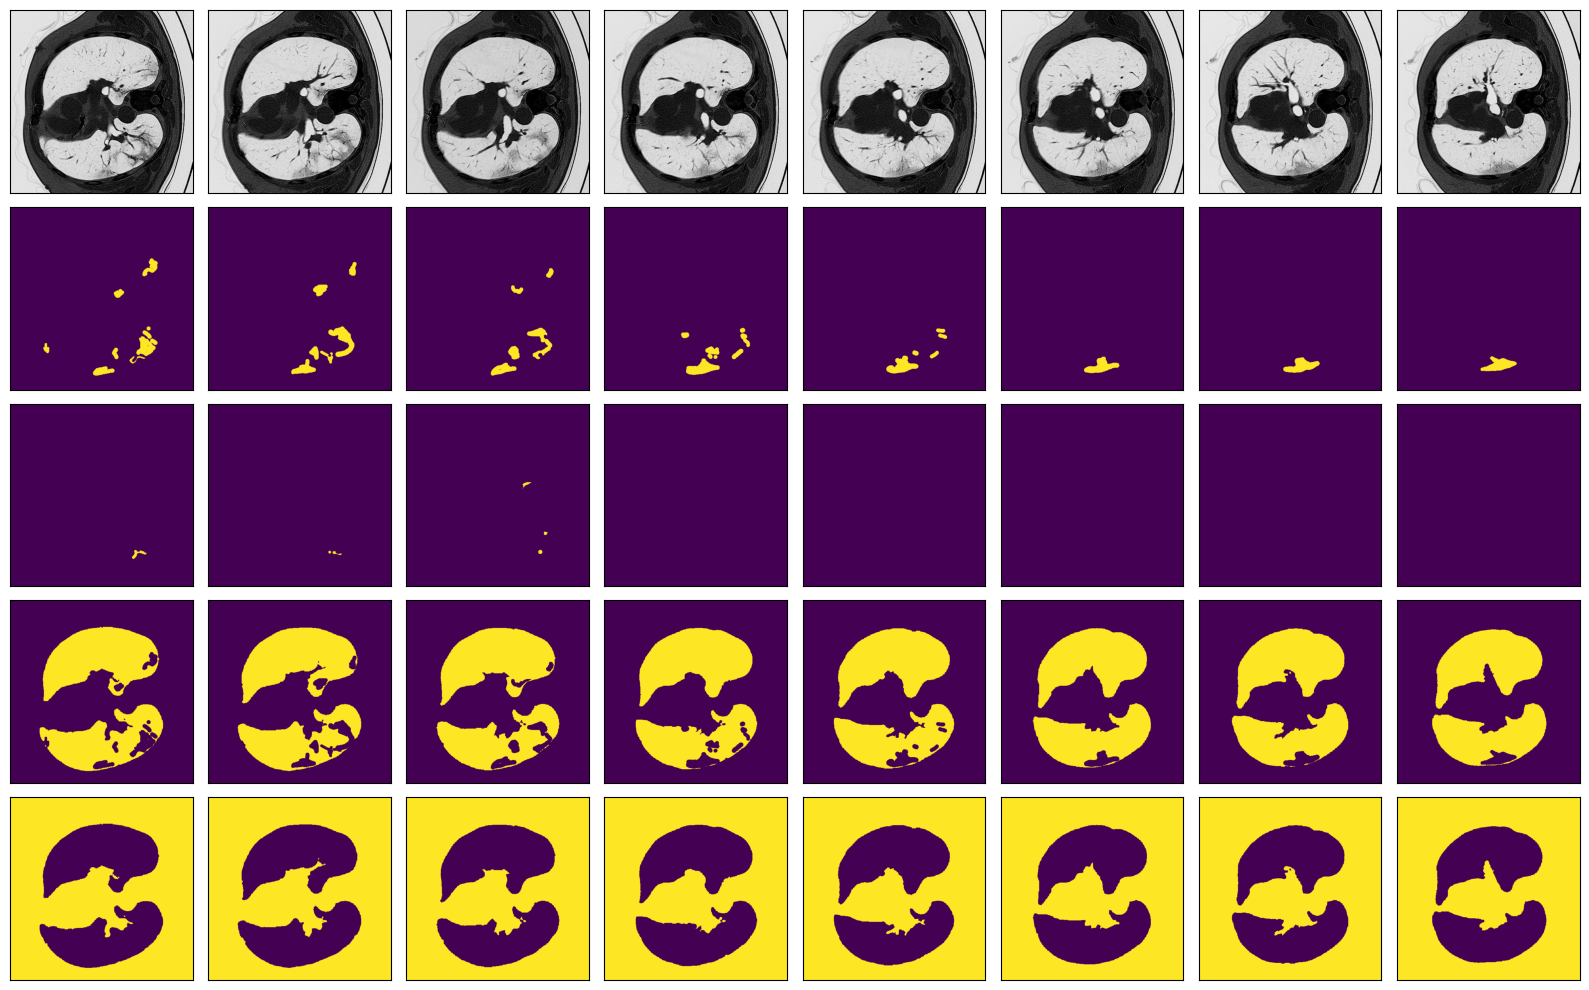

In [55]:
visualize(images_radiopedia[30:], masks_radiopedia[30:])

El objetivo del siguiente bloque de codigo es convertir de one hot encoding con los valores de todos los pixeles y el que corresponde a la clase como 1, mientras que el resto son 0 a una forma donde directamente este el indice de la clase.

Por ello declaramos la paletta con las clases y para las mascaras de radiopedia y medseg ejecutamos la función onehot_to_mask() y con squeeze() eliminamos una dimensión adicional, cambiando la forma de representar la información de la clase. Esto es necesario porque CrossEntropyLoss necesita que la mascara tenga un indice entero por píxel.

Hot encoded mask size:  (829, 512, 512, 4)
Paletted mask size: (100, 512, 512)


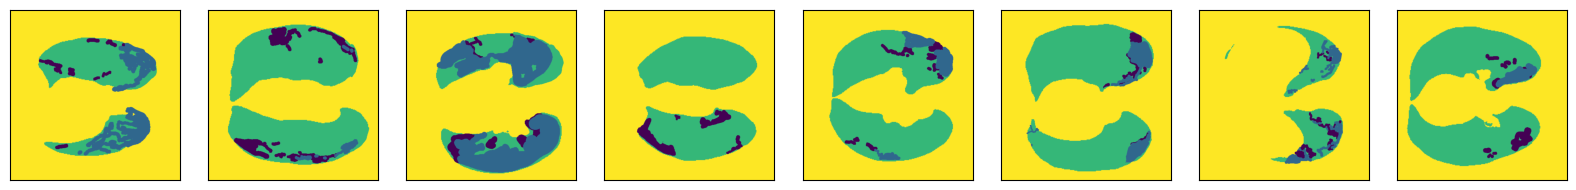

In [56]:
palette = [[0], [1], [2],[3]]
masks_radiopedia_recover = onehot_to_mask(masks_radiopedia, palette).squeeze()  # shape = (H, W)

masks_medseg_recover = onehot_to_mask(masks_medseg, palette).squeeze()  # shape = (H, W)

print('Hot encoded mask size: ',masks_radiopedia.shape)
print('Paletted mask size:',masks_medseg_recover.shape)

visualize(masks_medseg_recover[30:],hot_encode=False)

## Preprocess images:

En el siguiente bloque de codigo se ejecuta la limpieza y estandarización de las imagenes, donde se utiliza la función preprocess_images con los diferentes conjuntos de imagenes.

En esta se realiza el clipping con la función de contener los valores atipicos que pueden ser causados por aire fuera del cuerpo, ruido, metal, diferencias entre escaners, etc, en un rango definido para limitar aquellos valores muy grandes o muy pequeños.

Si no utilizaramos esta técnica los valores extremos podrían influir mucho en el modelo y dificultar su aprendizaje. Además de que de esta forma no eliminamos imagenes o pixeles, solo reemplazamos los valores extremos.

Finalmente se aplican estas transformaciones a los 3 conjuntos de imagenes para que todos se encuentren en la misma escala, porque si aplicaramos escalas diferentes para cada uno, un mismo valor en la imagen de CT podría representar cosas distintas para el modelo.

In [57]:
images_radiopedia, mean_std = preprocess_images(images_radiopedia)
images_medseg, _ = preprocess_images(images_medseg, mean_std)
test_images_medseg, _ = preprocess_images(test_images_medseg, mean_std)

mean -451.6488342285156, std 458.56787109375
mean -451.6488342285156, std 458.56787109375
mean -451.6488342285156, std 458.56787109375


En este bloque se utiliza la función plot_hists() con el propósito de comparar la distribución de intensidades después de preprocesado de los datos.

Esto es importante porque nos permite verificar si los histogramas quedaron alineados de forma similar. Si estos fueran sustancialmente diferentes podría indicar problemas como diferentes escalas de intensidad, problemas en el preprocesado, valores atipicos, etc.

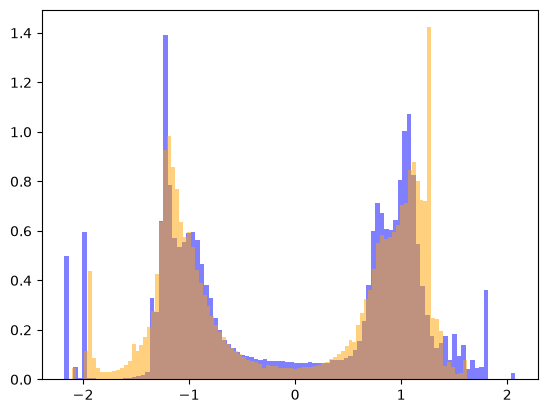

In [58]:
plot_hists(test_images_medseg, images_radiopedia)

## Split/Train

Para realizar la separación de los datos, primero recuperamos nuevamente los valores de las mascaras con la función onehot_to_mask() y se definen los indices para el conjunto de validación (0 a 23) y entrenamiento (24 a 99).

Después se asignan las imagenes y mascaras con los valores de estos indices para estos dos conjuntos.

Sin embargo aquí identificamos una posible mejora, ya que los indices no se eligen aleatoriamente, así que si tuvieramos un dataset ordenado por paciente o severidad, las primeras 24 imagenes tendrían valores que podrían no representar del todo bien al conjunto completo. Por ello una separación estratificada sería más segura.

In [59]:
masks_radiopedia_recover = onehot_to_mask(masks_radiopedia, palette).squeeze()  # shape = (H, W)
masks_medseg_recover     = onehot_to_mask(masks_medseg, palette).squeeze()  # shape = (H, W)

val_indexes, train_indexes = list(range(24)), list(range(24, 100))

train_images = np.concatenate((images_medseg[train_indexes], images_radiopedia))
train_masks  = np.concatenate((masks_medseg_recover[train_indexes], masks_radiopedia_recover))
val_images   = images_medseg[val_indexes]
val_masks    = masks_medseg_recover[val_indexes]

batch_size = len(val_masks)

del masks_medseg_recover
del masks_radiopedia_recover
del images_radiopedia
del masks_radiopedia
del images_medseg
del masks_medseg

## Data generator and augmentations

En el siguiente bloque de codigo se aplican transformaciones y aumento de datos.

Para los aumentos de entrenamiento, primero se hace una rotación, en donde ayuda a que el 90% de las imagenes rote, lo que beneficia al modelo porque no dependerá de una orientación exacta y produce nuevas variantes sin recolectar nuevas imagenes, con el parametro de BORDER_REPLICATE rellena las esquinas copiando pixeles cercanos.

Después se hace un recorte aleatorio, que puede tener una altura entre 384 y 512 pixeles, para simular diferentes niveles de acercamiento, cambia la posición aparente de las lesiones y mejora la capacidad del modelo de generalizar, sin embargo un recorte puede eliminar parte de la zona que nos interesa o producir muestras sin la clase de interes.

Como siguiente paso se realiza un giro horizontal, donde la mitad de las imagenes se pueden ver afectadas, esto se realiza para que los pulmones presenten una simetria, porque una muestra de interes puede aparecer de ambos lados.

Para los aumentos de validación únicamente se redimensionan, a 256x256, es decir tienen 4 veces menos información, lo que representa un menor uso de memoria y un entrenamiento más rapido con el posible coste de perder detalles o que las zonas de interés puedan ser más dificiles de segmentar.

In [60]:
SOURCE_SIZE = 512
TARGET_SIZE = 256

train_augs = albumentations.Compose([
    albumentations.Rotate(limit=360, p=0.9, border_mode=cv2.BORDER_REPLICATE),
    albumentations.RandomSizedCrop((int(SOURCE_SIZE * 0.75), SOURCE_SIZE), 
                                   (TARGET_SIZE, TARGET_SIZE), 
                                   interpolation=cv2.INTER_NEAREST),
    albumentations.HorizontalFlip(p=0.5),

])

val_augs = albumentations.Compose([
    albumentations.Resize(TARGET_SIZE, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
])

En este bloque de codigo se crean los conjuntos de datos y los dataloaders.

Primero se instancian dos objetos de la clase Dataset para los conjuntos de train y validation, cada uno con sus respectivas mascaras, imagenes y los aumentos realizados en el bloque anterior.

Por último se instancian dos objetos de la clase DataLoader, donde hay una diferencia en el parametro de shuffle para cada uno de los dos conjuntos. Para train se manda como `true` porque se desea que el modelo no aprenda patrones relacionados con el orden del dataset y para val se manda como `false` porque nos interesa que sea fácil de reproducir la evaluación. 

In [61]:
train_dataset    = Dataset(train_images, train_masks, train_augs)
val_dataset      = Dataset(val_images, val_masks, val_augs)       
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Este bloque permite inspeccionar visualmente la alineación entre las imágenes y sus máscaras en las primeras ocho muestras de un lote, así como observar la representación de las cuatro clases después de las transformaciones.

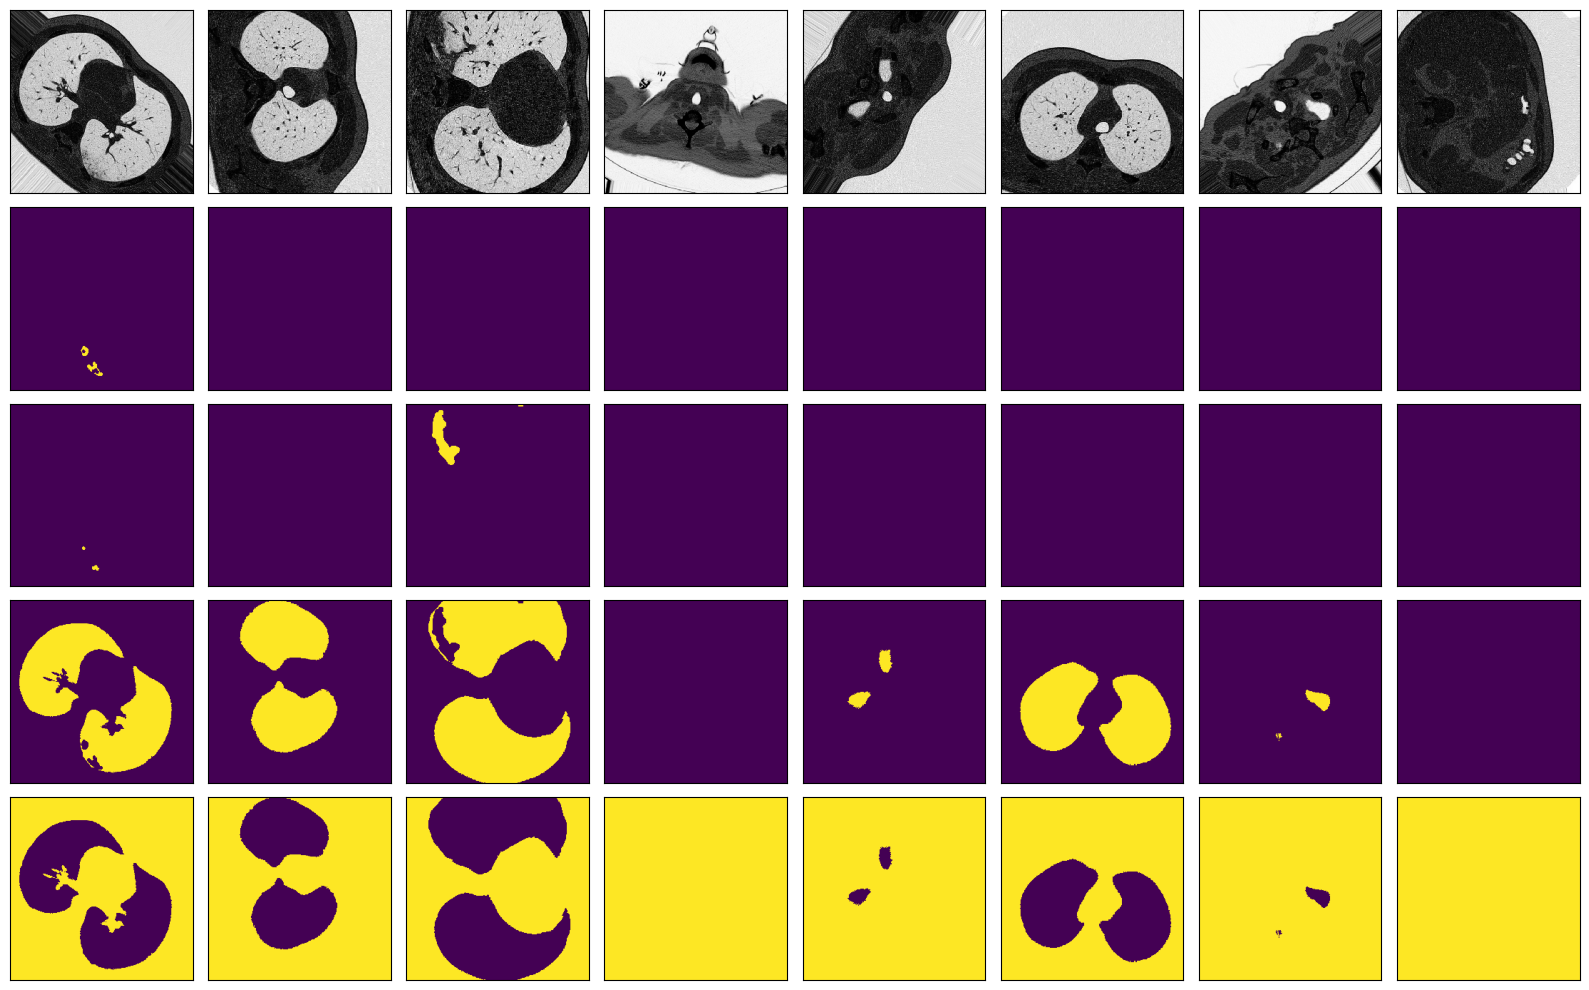

In [62]:
i,train_data     = next(enumerate(train_dataloader))
mask_hot_encoded = mask_to_onehot(torch.unsqueeze(train_data[1],-1).numpy(),palette)
visualize(train_data[0].permute(0, 2, 3,1),mask_hot_encoded)

In [64]:
model = smp.Unet('efficientnet-b2',in_channels=1, encoder_weights='imagenet',classes=4, activation=None, encoder_depth=5, decoder_channels=[256, 128, 64, 32, 16])

In [65]:
max_lr       = 1e-2
epoch        = 10
weight_decay = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
sched     = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epoch,
                                            steps_per_epoch=len(train_dataloader))

history = fit(epoch, model, train_dataloader, val_dataloader, criterion, optimizer, sched)

  0%|          | 0/38 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
torch.save(model, 'Unet-efficientnet.pt')

: 

: 

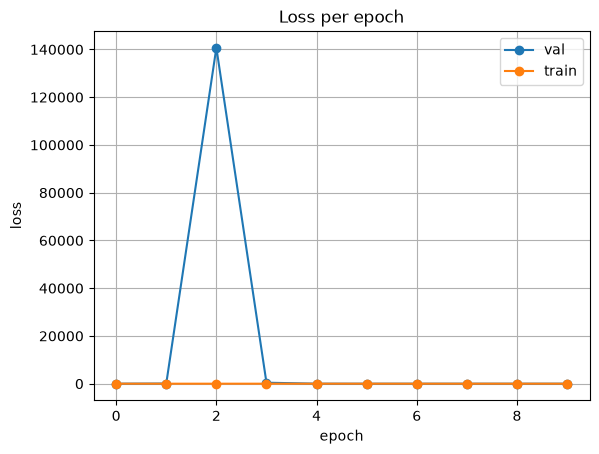

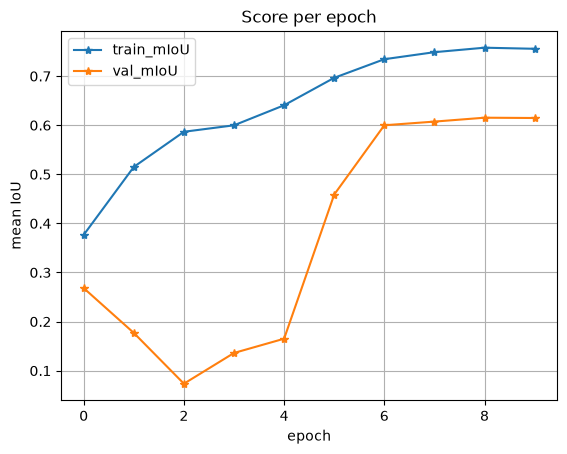

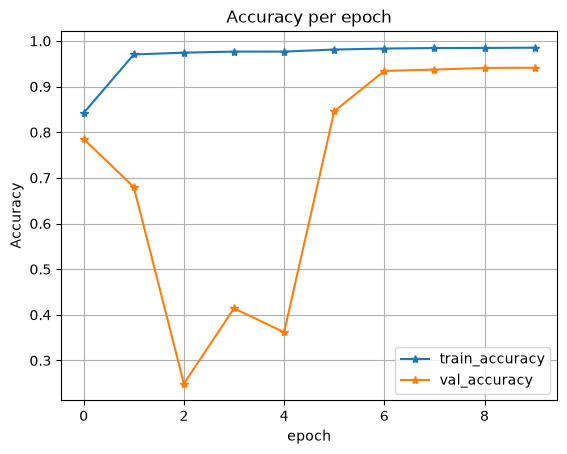

: 

: 

In [ ]:
plot_loss(history)
plot_score(history)
plot_acc(history)

## Evaluation

### Result

In [ ]:
image, mask             = next(iter(val_dataloader))
pred_mask, score,output = predict_image_mask_miou(model, image, mask)
semantic_map            = mask_to_onehot(torch.unsqueeze(mask,-1).numpy(),palette)

: 

: 

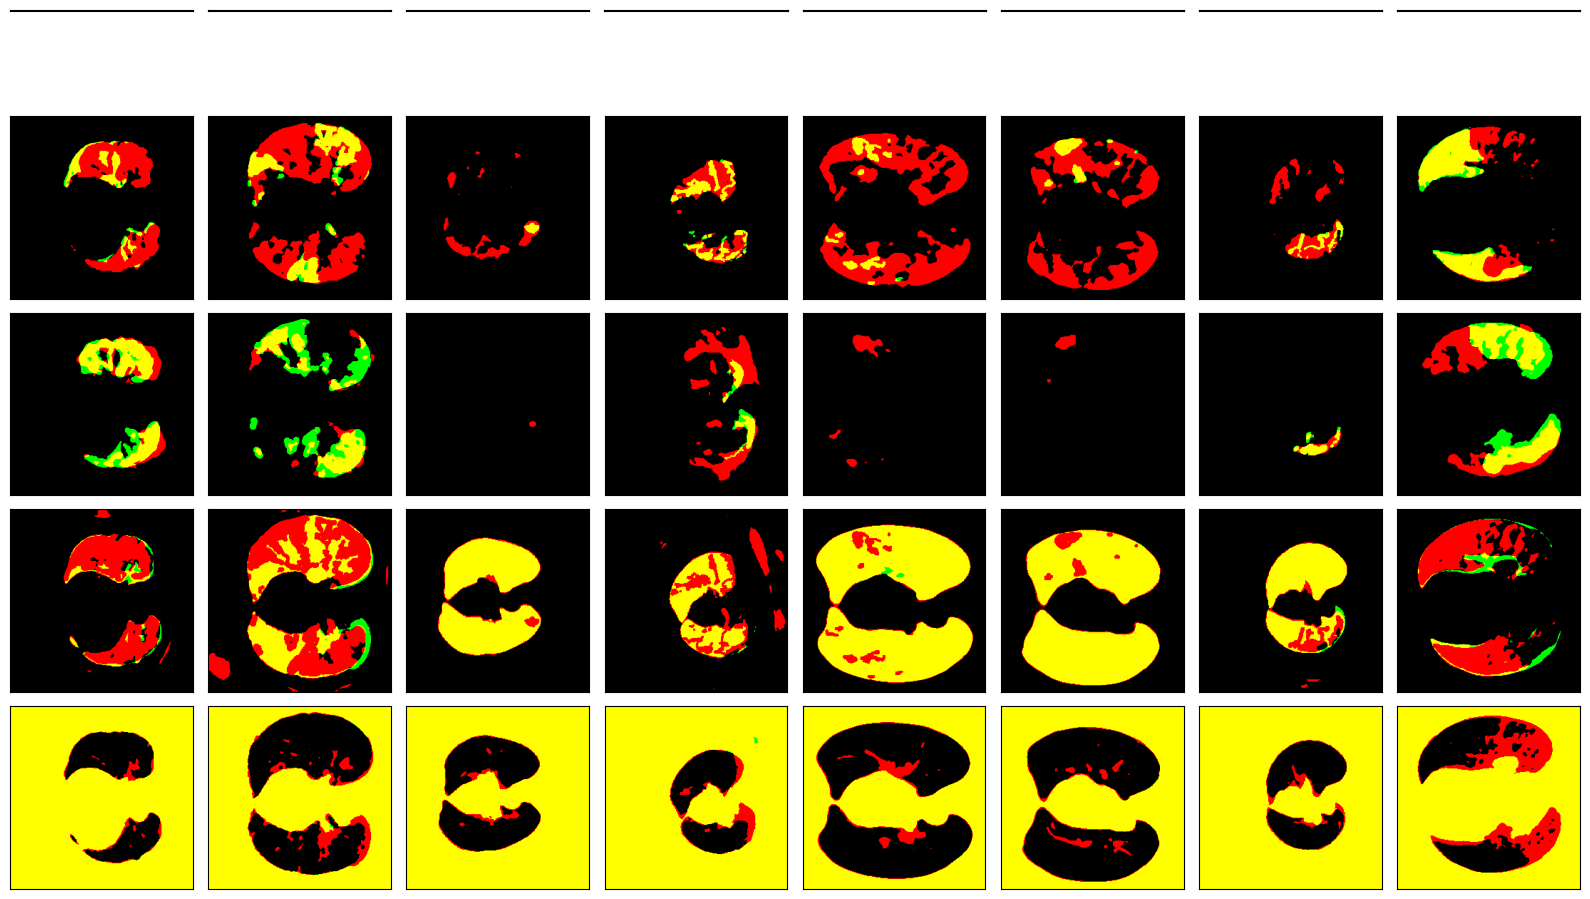

: 

: 

In [ ]:
visualize(image.cpu(), semantic_map, pred_batch=output.cpu())

In [ ]:
mob_miou = miou_score(model, val_dataloader)
mob_miou

100%|██████████| 1/1 [00:01<00:00,  1.51s/it]


[np.float64(0.6146931143042693)]

: 

: 

In [ ]:
del train_images
del train_masks

: 

: 

## Test preds:

torch.Size([10, 256, 256, 1])
(256, 256, 1)
(10, 256, 256, 4)


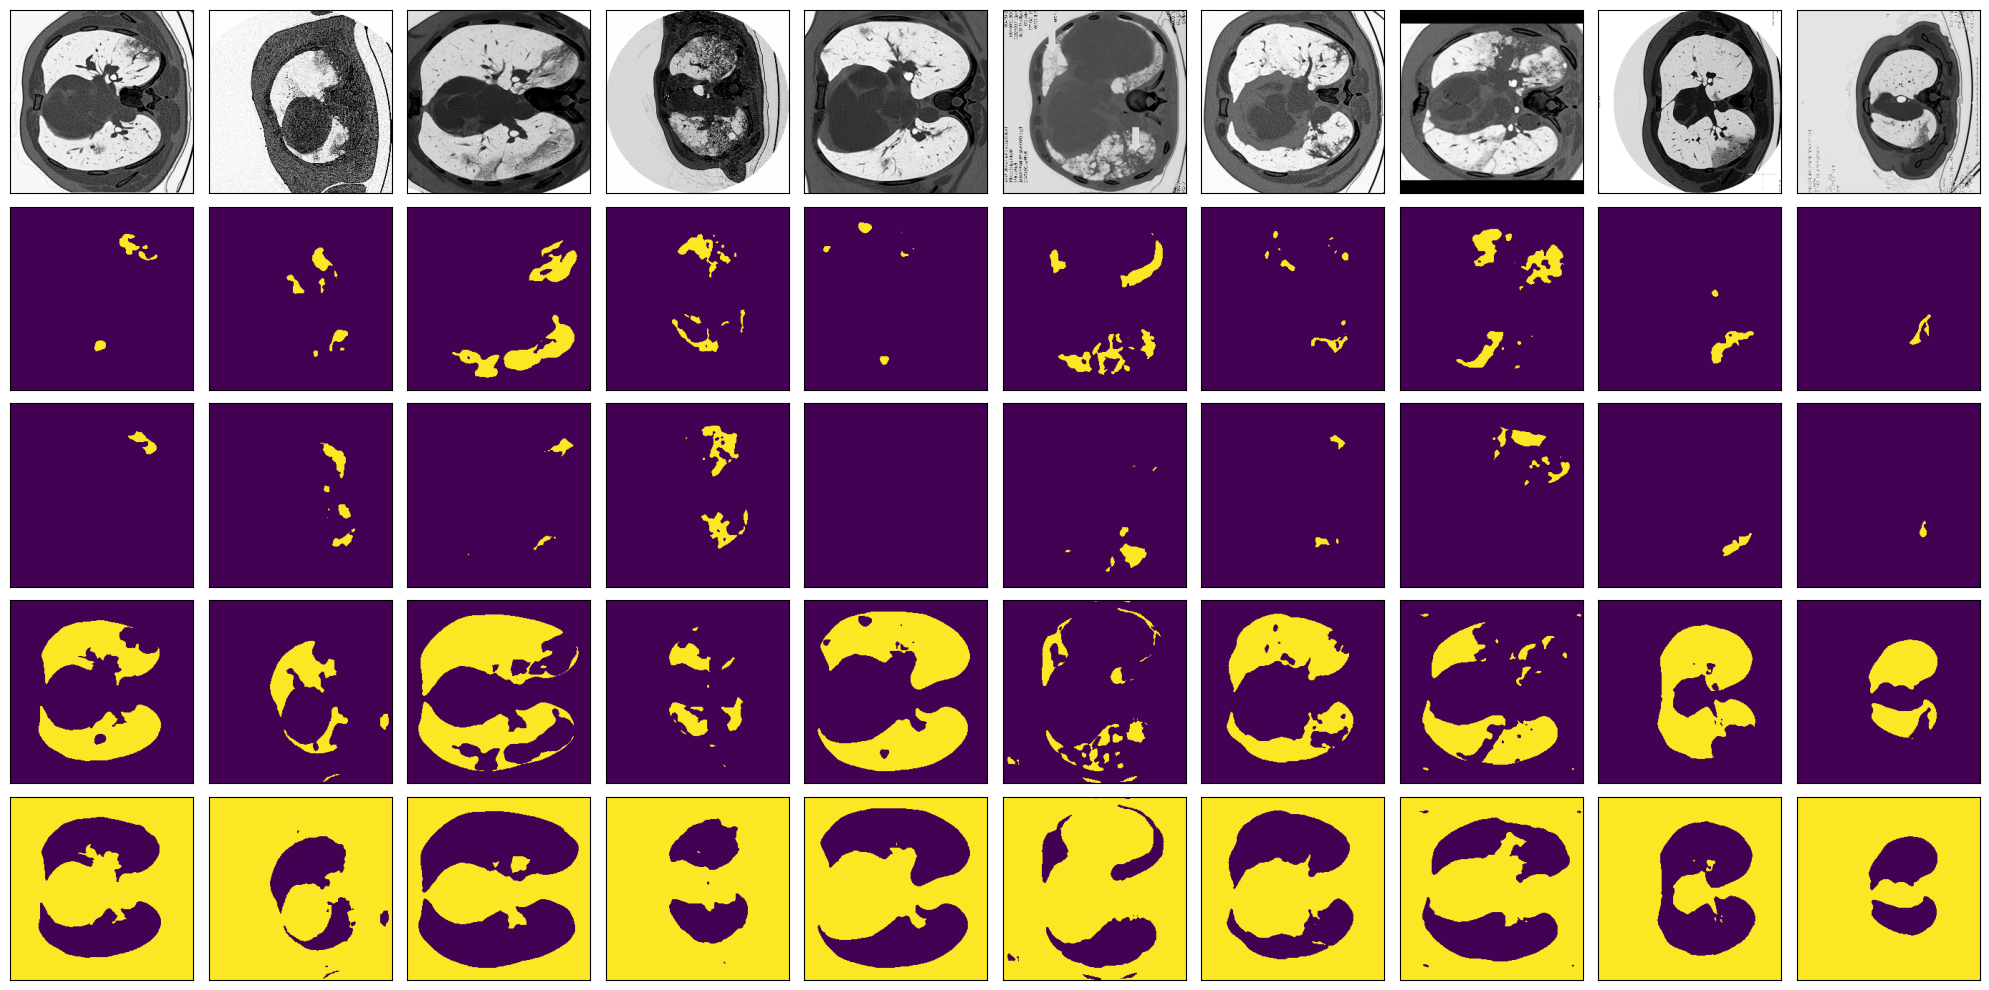

: 

: 

In [ ]:
image_batch = np.stack([val_augs(image=img)['image'] for img in test_images_medseg], axis=0)
print(torch.from_numpy(image_batch).shape)
print(image_batch[i].shape)
#output = test_predict(model, torch.from_numpy(image_batch).permute(0, 3, 1,2))
output = np.zeros((10,256,256,4))
for i in range(10):   
    output[i] = test_predict(model, image_batch[i]).cpu().numpy()
print(output.shape)
test_masks_prediction = output > 0.5
visualize(image_batch, test_masks_prediction, num_samples=len(test_images_medseg))

## Resize prediction to original size 

In [ ]:
test_masks_prediction_original_size = scipy.ndimage.zoom(test_masks_prediction[..., :-2], (1, 2, 2, 1), order=0)
test_masks_prediction_original_size.shape

(10, 512, 512, 2)

: 

: 

In [ ]:
pd.DataFrame(
             data=np.stack((np.arange(len(test_masks_prediction_original_size.ravel())), 
                            test_masks_prediction_original_size.ravel().astype(int)),
                            axis=-1), 
             columns=['Id', 'Predicted'])\
.set_index('Id').to_csv('sub.csv')

: 

: 